## 1) Libraries

## 1) Libraries

In [36]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict, cross_validate, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## 2) Data

- Read, clean and preprocess the training and test sets with the same sequence of operations.

In [37]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [38]:
# info from airbnb regarding to super host
# relevant metrics: overall rating, response rate, cancellation rate, booking consistency, occupancy rate, average daily rate, repeat guest rate, commmitment rate, accuracy(photos)

In [39]:
# drop useless columns
drop_cols = ['listing_location', 'description', 'host_location', 'host_about', 'host_since','host_neighbourhood', 'host_verifications', 'neighbourhood_cleansed',
             'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'minimum_nights',
             'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm',
             'maximum_nights_avg_ntm', 'first_review', 'last_review', 'host_response_time']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

# convert to pure numbs

def convert_percent(x):
    return x.str.rstrip('%').astype('float')

for col in ['host_response_rate', 'host_acceptance_rate']:
    train[col] = convert_percent(train[col])
    test[col] = convert_percent(test[col])

bools_cols = ['host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bools_cols:
    train[col] = train[col].astype('bool')
    test[col] = test[col].astype('bool')

In [40]:
# check missing
print("Missing values in TRAIN:")
print(train.isnull().sum().sort_values(ascending=False))

print("Missing values in TEST:")
print(test.isnull().sum().sort_values(ascending=False))

Missing values in TRAIN:
reviews_per_month                               2205
review_scores_accuracy                          2205
review_scores_cleanliness                       2205
review_scores_checkin                           2205
review_scores_communication                     2205
review_scores_location                          2205
review_scores_value                             2205
review_scores_rating                            2205
host_response_rate                               829
host_acceptance_rate                             436
host_total_listings_count                          1
host_listings_count                                1
calculated_host_listings_count_entire_homes        0
instant_bookable                                   0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
calculated_host_listings_count                     0
id                                                 0
number_of_reviews_l30

In [41]:
# impute
review_cols = [col for col in train.columns if 'review_scores' in col] + ['reviews_per_month']
for col in review_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

rate_cols = ['host_response_rate', 'host_acceptance_rate']
for col in rate_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

cat_cols = ['host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']
for col in cat_cols:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

listings_cols = ['host_listings_count', 'host_total_listings_count']
for col in listings_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

y_train = train['host_is_superhost']

X_train = train.drop(columns=['id', 'host_is_superhost'])
X_test = test.drop(columns=['id'])

In [42]:
# create relevant predictors
X_train['occupancy_rate'] = 1 - (X_train['availability_365'] / 365)
X_train['host_engagement'] = X_train['host_response_rate'] * X_train['host_acceptance_rate']

X_test['occupancy_rate'] = 1 - (X_test['availability_365'] / 365)
X_test['host_engagement'] = X_test['host_response_rate'] * X_test['host_acceptance_rate']

X_train['response_occupancy'] = X_train['host_response_rate'] * X_train['occupancy_rate']
X_test['response_occupancy'] = X_test['host_response_rate'] * X_test['occupancy_rate']

In [43]:
# scaling
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [44]:
#poly = PolynomialFeatures(degree=2, include_bias=False)
#X_train_poly = poly.fit_transform(X_train_scaled)
#X_test_poly = poly.transform(X_test_scaled)

In [45]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=12)

grid = {'n_neighbors': np.arange(5,24,2), 'weights': ['distance'], 'p': [1]}

model = KNeighborsClassifier()
gscv = GridSearchCV(model, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gscv.fit(X_train_scaled, y_train)

print("Best params:", gscv.best_params_)
print("Best roc_auc:", gscv.best_score_)

NameError: name 'X_train_scaled' is not defined

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score



bag = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=13, p=1, weights='distance'),
    n_estimators=30,      
    random_state=12,
    max_features=0.8,
    max_samples=0.8,
    bootstrap=True,
    bootstrap_features=True,
    n_jobs=-1
)

bag_auc = cross_val_score(
    bag,
    X_train_scaled, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
).mean()

print("Bagged KNN AUC:", bag_auc)

Bagged KNN AUC: 0.9095213830025171


In [ ]:
# xgboost
grid = {
    'learning_rate': [0.03, 0.05, 0.07, 0.1, 1 , 10],
    'max_depth': np.arange(5, 11),
    'subsample': np.arange(0.5, 1.0, 0.1),
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1, 2],
    'gamma': [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1, 2, 5]
}

xgb = XGBClassifier(
    random_state=12,
    n_estimators=300,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

rscv = RandomizedSearchCV(
    xgb,
    grid,
    n_iter=50,
    cv=cv,
    random_state=12,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

rscv.fit(X_train, y_train)

print("Best params:", rscv.best_params_)
print("Best roc_auc:", rscv.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8999999999999999, 'reg_lambda': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.05, 'colsample_bytree': 1.0}
Best roc_auc: 0.9656000334800512


In [ ]:
tuned_model = XGBClassifier(
    random_state=12,
    n_estimators=500,
    subsample=1,
    reg_lambda=1,
    max_depth=7,
    learning_rate=0.07,
    colsample_bytree=0.9
)
tuned_model.fit(X_train, y_train)
test_probs = tuned_model.predict_proba(X_test)[:, 1]
# 0.9677

In [ ]:
tuned_model = XGBClassifier(
    random_state=12,
    n_estimators=400,
    subsample=1,
    reg_lambda=1,
    max_depth=7,
    learning_rate=0.07,
    colsample_bytree=0.9
)
tuned_model.fit(X_train, y_train)
test_probs = tuned_model.predict_proba(X_test)[:, 1]
# 0.9678

In [ ]:
importances = tuned_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns
plt.figure(figsize=(10,6))
plt.title('XGBoost Feature Importance (Gain)')
plt.bar(range(15), importances[indices][:15], align='center')
plt.xticks(range(15), feature_names[indices][:15], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': np.arange(3, 10),
    'max_features': [0.5, 0.7, 0.9, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

base_model = RandomForestClassifier(random_state=12)

rscv_rf = RandomizedSearchCV(
    base_model,
    grid,
    n_iter=10,
    cv=cv,
    random_state=12,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

rscv_rf.fit(X_train, y_train)

print("Best params:", rscv_rf.best_params_)
print("Best roc_auc:", rscv_rf.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 300, 'max_features': 0.5, 'max_depth': 9}
Best roc_auc: 0.9305672200224014


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_bagging.py:769: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_bagging.py:775: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


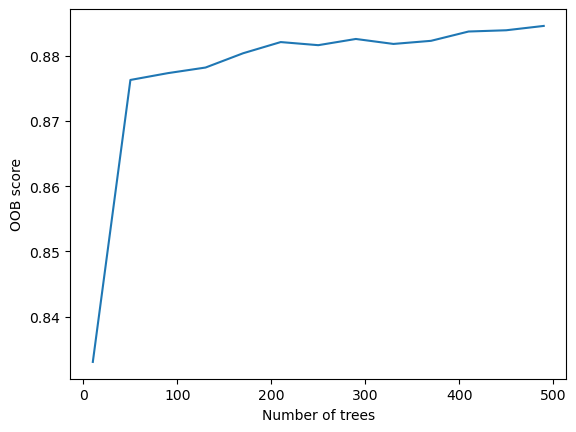

In [ ]:
# bagging
base = DecisionTreeClassifier(random_state=12)

model = BaggingClassifier(
    random_state=12,
    estimator=base,
    n_estimators=50,
    oob_score=True
)
model.fit(X_train, y_train)

oob_score = []

num_trees = np.arange(10, 500, 40)

for num_tree in num_trees:
    base = DecisionTreeClassifier(random_state=12)
    model = BaggingClassifier(
        random_state=12,
        estimator=base,
        n_estimators=num_tree,
        oob_score=True
    )
    model.fit(X_train, y_train)
    oob_score.append(model.oob_score_)

plt.plot(num_trees, oob_score)
plt.xlabel('Number of trees')
plt.ylabel('OOB score')
plt.show()

In [ ]:
base = DecisionTreeClassifier(random_state=12)

model = BaggingClassifier(
    random_state=12,
    estimator=base,
    n_estimators=450,
    oob_score=True
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)
grid = {
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
    'bootstrap_features': [True, False]
}

rscv = RandomizedSearchCV(
    model,
    grid,
    n_iter=10,
    cv=cv,
    random_state=12,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

rscv.fit(X_train, y_train)

print("Best params:", rscv.best_params_)
print("Best roc_auc:", rscv.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best params: {'max_samples': 1.0, 'max_features': 1.0, 'bootstrap_features': True}
Best roc_auc: 0.9513741107770926


In [ ]:
# adaboost
base = DecisionTreeClassifier(random_state=12)

grid = {
    'estimator__max_depth': np.arange(1,10,2),
    'n_estimators': np.arange(50, 500, 50),
    'learning_rate': [0.01, 0.1, 1, 10]
}

ada = AdaBoostClassifier(
    random_state=12,
    estimator=base,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

rscv_ada = RandomizedSearchCV(
    ada,
    grid,
    n_iter=10,
    cv=cv,
    random_state=12,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

rscv_ada.fit(X_train, y_train)

print("Best params:", rscv_ada.best_params_)
print("Best roc_auc:", rscv_ada.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

Best params: {'n_estimators': 400, 'learning_rate': 0.1, 'estimator__max_depth': 5}
Best roc_auc: 0.959533626279438


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [ ]:
# catboost
cat = CatBoostClassifier(
    random_state=12,
    verbose=False,
    grow_policy='Lossguide'
)

param_grid = {'num_leaves': Integer(4, 64),
              'learning_rate': Real(0.0001, 1.0),
               'reg_lambda':Real(0, 1e4),
                'n_estimators':Integer(2, 2000),
                'subsample': Real(0.1,1.0),
                'colsample_bylevel': Real(0.1, 1.0)}

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=1)

rscv_cat = BayesSearchCV(
    estimator=cat,
    search_spaces=param_grid,
    n_iter=20, 
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=12
)

rscv_cat.fit(X_train, y_train)

print("Best params:", rscv_cat.best_params_)
print("Best roc_auc:", rscv_cat.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

Training has stopped (degenerate solution on iteration 26, probably too small l2-regularization, try to increase it)


Best params: OrderedDict({'colsample_bylevel': 1.0, 'learning_rate': 0.8324262757254876, 'n_estimators': 2000, 'num_leaves': 47, 'reg_lambda': 7654.235740610272, 'subsample': 0.9573246669522569})
Best roc_auc: 0.961981057652066


In [46]:
# gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# Base model
gb = GradientBoostingClassifier(random_state=12)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [400, 800, 1000, 1200],
    'learning_rate': [0.03, 0.05, 0.07, 0.1],
    'max_depth': [8, 9, 10, 11, 12],
    'subsample': [0.8, 0.9, 1.0],
}

# Stratified K-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

# Randomized search
rscv = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    n_iter=10,     
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=12
)

# Fit
rscv.fit(X_train, y_train)

# Print best results
print("Best ROC-AUC: {:.4f}".format(rscv.best_score_))
print("Best Parameters:", rscv.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END learning_rate=0.05, max_depth=10, n_estimators=400, subsample=1.0; total time=  53.5s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=400, subsample=1.0; total time=  53.9s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=400, subsample=1.0; total time=  54.0s
[CV] END learning_rate=0.05, max_depth=8, n_estimators=800, subsample=0.8; total time= 1.1min
[CV] END learning_rate=0.05, max_depth=8, n_estimators=800, subsample=0.8; total time= 1.1min
[CV] END learning_rate=0.05, max_depth=8, n_estimators=800, subsample=0.8; total time= 1.1min
[CV] END learning_rate=0.05, max_depth=8, n_estimators=800, subsample=0.8; total time= 1.1min
[CV] END learning_rate=0.05, max_depth=8, n_estimators=800, subsample=0.8; total time= 1.1min
[CV] END learning_rate=0.05, max_depth=10, n_estimators=400, subsample=1.0; total time=  57.6s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=400, subsample=1.0; total time=  

In [ ]:
tuned_model = GradientBoostingClassifier(
    random_state=12,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.9
)
tuned_model.fit(X_train, y_train)
test_probs = tuned_model.predict_proba(X_test)[:, 1]
# 0.9700